In [1]:
import os
import zipfile
import pyarrow.parquet as pq
import pandas as pd

folder = r"F:\sanazi\python\data science\code\tamrin\proje\Tennis Schema\Tennis Schema\tennis_data"

data = {}

for file in os.listdir(folder): 
    if file.endswith(".zip"):

        zip_path = os.path.join(folder, file) 

        with zipfile.ZipFile(zip_path) as z: 
            for parquet_file in z.namelist(): 
                if parquet_file.endswith(".parquet"): 

                    with z.open(parquet_file) as f:
                        df = pq.read_table(f).to_pandas()
                    table_name =os.path.basename(os.path.dirname(parquet_file))[4:-8] + os.path.basename(parquet_file)[:-17]

                    if table_name not in data:
                        data[table_name] = [] 
                    data[table_name].append(df)

for table_name in data:
    data[table_name] = pd.concat(data[table_name], ignore_index=True) 

print(data.keys())

C:\Users\sepehr\AppData\Local\Temp\ipykernel_932\2021478474.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data[table_name] = pd.concat(data[table_name], ignore_index=True)


dict_keys(['matchaway_team', 'matchaway_team_score', 'matchevent', 'matchhome_team', 'matchhome_team_score', 'matchround', 'matchseason', 'matchtime', 'matchtournament', 'matchvenue', 'oddsodds', 'point_by_pointpbp', 'statisticsstatistics', 'tennis_powerpower', 'votesvotes'])


In [2]:
import pandas as pd


home = data["matchhome_team"][["player_id", "full_name", "height", "current_rank"]]
away = data["matchaway_team"][["player_id", "full_name", "height", "current_rank"]]


players = pd.concat([home, away], ignore_index=True)


players = players.drop_duplicates(subset="player_id")


players = players.dropna(subset=["height", "current_rank"])


correlation = players["height"].corr(players["current_rank"])

print("Correlation:", correlation)

Correlation: 0.10512440005347558


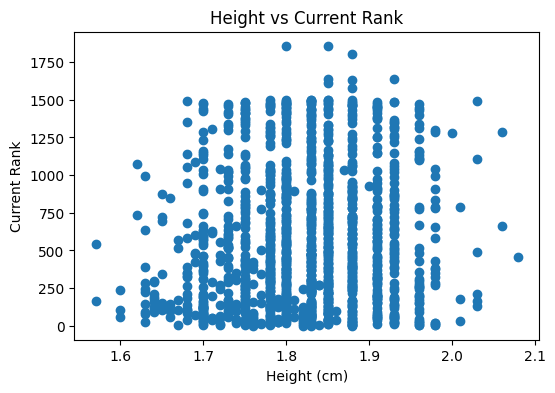

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(players["height"], players["current_rank"])

plt.xlabel("Height (cm)")
plt.ylabel("Current Rank")
plt.title("Height vs Current Rank")

plt.show()

In [5]:
players["height"] = pd.to_numeric(players["height"], errors="coerce")
players["current_rank"] = pd.to_numeric(players["current_rank"], errors="coerce")

players = players.dropna(subset=["height", "current_rank"])

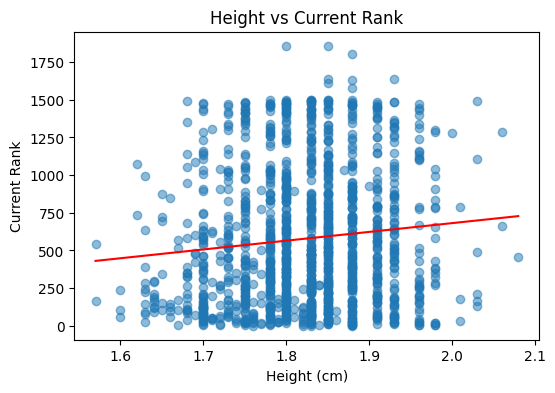

In [6]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.scatter(players["height"], players["current_rank"], alpha=0.5)

z = np.polyfit(players["height"].values,
               players["current_rank"].values, 1)

p = np.poly1d(z)

x = np.sort(players["height"].values)

plt.plot(x, p(x), color="red")

plt.xlabel("Height (cm)")
plt.ylabel("Current Rank")
plt.title("Height vs Current Rank")

plt.show()